In [1]:
import time
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
df = pd.read_csv('Weather_Dataset.csv')

In [3]:
df.shape

(8784, 8)

In [4]:
df.head()

,Date/Time,Temp_C,Dew Point Temp_C,Rel Hum_%,Wind Speed_km/h,Visibility_km,Press_kPa,Weather
0,1/1/2012 0:00,-1.8,-3.9,86,4,8.0,101.24,Fog
1,1/1/2012 1:00,-1.8,-3.7,87,4,8.0,101.24,Fog
2,1/1/2012 2:00,-1.8,-3.4,89,7,4.0,101.26,"Freezing Drizzle,Fog"
3,1/1/2012 3:00,-1.5,-3.2,88,6,4.0,101.27,"Freezing Drizzle,Fog"
4,1/1/2012 4:00,-1.5,-3.3,88,7,4.8,101.23,Fog


In [5]:
print(df['Weather'].value_counts())

Weather
Mainly Clear                               2106
Mostly Cloudy                              2069
Cloudy                                     1728
Clear                                      1326
Snow                                        390
Rain                                        306
Rain Showers                                188
Fog                                         150
Rain,Fog                                    116
Drizzle,Fog                                  80
Snow Showers                                 60
Drizzle                                      41
Snow,Fog                                     37
Snow,Blowing Snow                            19
Rain,Snow                                    18
Thunderstorms,Rain Showers                   16
Haze                                         16
Drizzle,Snow,Fog                             15
Freezing Rain                                14
Freezing Drizzle,Snow                        11
Freezing Drizzle                

### Preprocessing

In [6]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Date/Time           0
Temp_C              0
Dew Point Temp_C    0
Rel Hum_%           0
Wind Speed_km/h     0
Visibility_km       0
Press_kPa           0
Weather             0
dtype: int64


In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

df = pd.read_csv("Weather_Dataset.csv")

df = df.drop(columns=["Date/Time"], errors="ignore")

value_counts = df['Weather'].value_counts()
rare_classes = value_counts[value_counts < threshold].index
df = df[~df['Weather'].isin(rare_classes)]

X = df.drop("Weather", axis=1)
y = df["Weather"]

le = LabelEncoder()
y = le.fit_transform(y)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("scaler", StandardScaler())
        ]), X.columns)
    ]
)

X_processed = preprocessor.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Classes left:", len(np.unique(y)))


✅ Data Preprocessed Successfully
Train shape: (6964, 6)  Test shape: (1742, 6)
Classes left: 20


In [21]:
X.shape

(8706, 6)

# KNN

KNN Accuracy: 0.4494833524684271

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.52      0.48       265
           1       0.41      0.50      0.45       346
           2       0.25      0.12      0.17         8
           3       0.43      0.75      0.55        16
           4       0.75      1.00      0.86         3
           5       0.55      0.60      0.57        30
           6       0.33      0.50      0.40         2
           7       0.00      0.00      0.00         3
           8       0.25      0.33      0.29         3
           9       0.45      0.51      0.48       421
          10       0.43      0.33      0.37       414
          11       0.57      0.33      0.42        61
          12       0.00      0.00      0.00        38
          13       0.57      0.57      0.57        23
          14       0.00      0.00      0.00         4
          15       0.68      0.62      0.64        78
          16       0.50

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


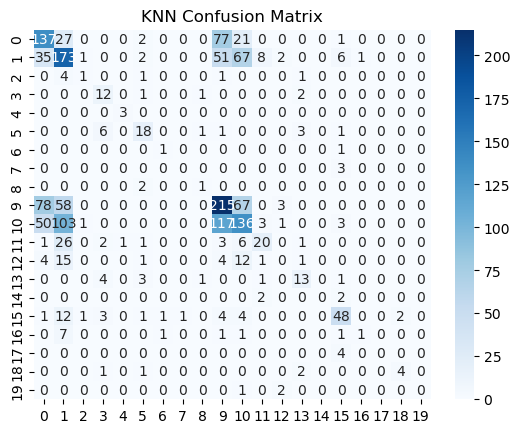

In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Evaluate
y_pred = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("KNN Confusion Matrix")
plt.show()


# SVM

SVM Accuracy: 0.41446613088404133

Classification Report:
               precision    recall  f1-score   support

           0       0.40      0.37      0.38       265
           1       0.36      0.43      0.39       346
           2       0.00      0.00      0.00         8
           3       1.00      0.06      0.12        16
           4       0.00      0.00      0.00         3
           5       0.43      0.73      0.54        30
           6       0.00      0.00      0.00         2
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         3
           9       0.42      0.59      0.49       421
          10       0.39      0.30      0.34       414
          11       0.45      0.21      0.29        61
          12       0.00      0.00      0.00        38
          13       0.41      0.57      0.47        23
          14       0.00      0.00      0.00         4
          15       0.68      0.73      0.70        78
          16       0.0

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


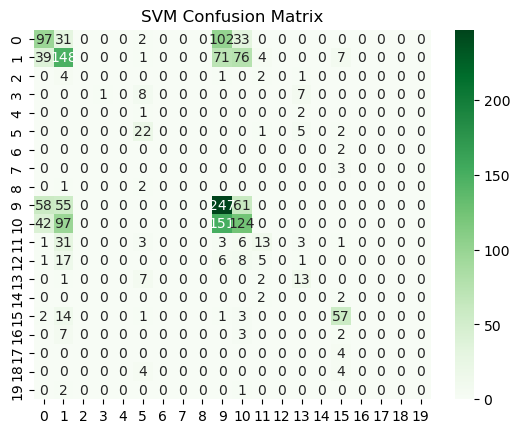

In [23]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", random_state=42)
svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Greens")
plt.title("SVM Confusion Matrix")
plt.show()


# Decision Tree

Decision Tree Accuracy: 0.44202066590126293

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.49      0.48       265
           1       0.45      0.48      0.46       346
           2       0.50      0.25      0.33         8
           3       0.35      0.44      0.39        16
           4       1.00      0.33      0.50         3
           5       0.70      0.63      0.67        30
           6       0.67      1.00      0.80         2
           7       0.20      0.33      0.25         3
           8       0.20      0.33      0.25         3
           9       0.46      0.47      0.46       421
          10       0.39      0.37      0.38       414
          11       0.38      0.28      0.32        61
          12       0.09      0.08      0.09        38
          13       0.70      0.70      0.70        23
          14       0.00      0.00      0.00         4
          15       0.58      0.59      0.59        78
          16

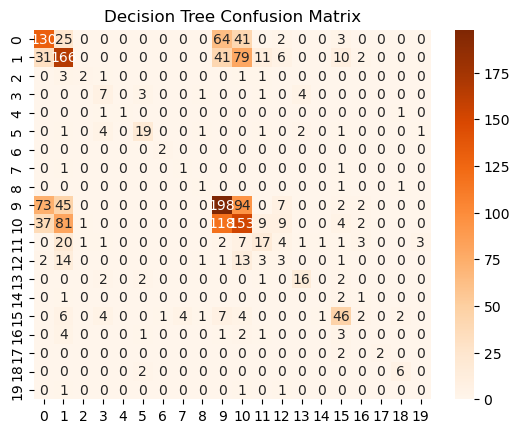

In [24]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Oranges")
plt.title("Decision Tree Confusion Matrix")
plt.show()


# Random Forest

 Random Forest Results
Accuracy: 0.5407577497129736

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.55      0.55       265
           1       0.52      0.58      0.55       346
           2       0.33      0.12      0.18         8
           3       0.61      0.69      0.65        16
           4       1.00      1.00      1.00         3
           5       0.68      0.77      0.72        30
           6       1.00      0.50      0.67         2
           7       1.00      0.33      0.50         3
           8       0.67      0.67      0.67         3
           9       0.54      0.57      0.56       421
          10       0.49      0.49      0.49       414
          11       0.62      0.46      0.53        61
          12       0.29      0.05      0.09        38
          13       0.54      0.65      0.59        23
          14       0.50      0.25      0.33         4
          15       0.75      0.72      0.73        78
    

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


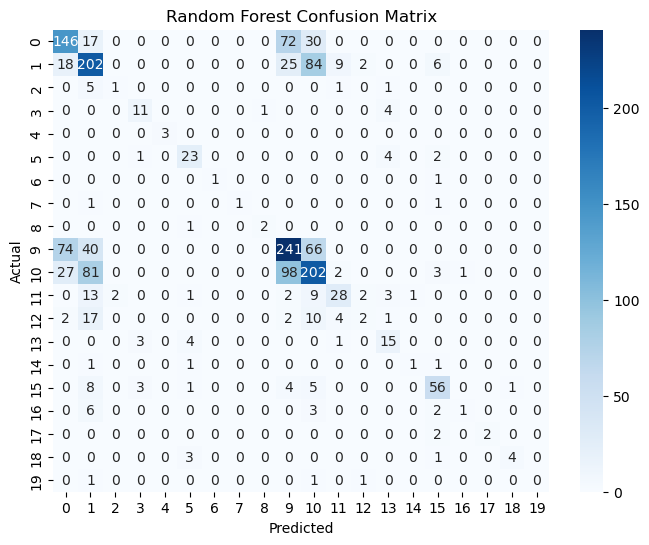

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluation
print(" Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# AdaBoost

 AdaBoost Results
Accuracy: 0.3019517795637199

Classification Report:
               precision    recall  f1-score   support

           0       0.32      0.58      0.42       265
           1       0.35      0.03      0.05       346
           2       0.00      0.00      0.00         8
           3       0.00      0.00      0.00        16
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00        30
           6       0.00      0.00      0.00         2
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00       421
          10       0.29      0.72      0.41       414
          11       0.16      0.30      0.21        61
          12       0.17      0.03      0.05        38
          13       1.00      0.04      0.08        23
          14       0.00      0.00      0.00         4
          15       0.56      0.56      0.56        78
         

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


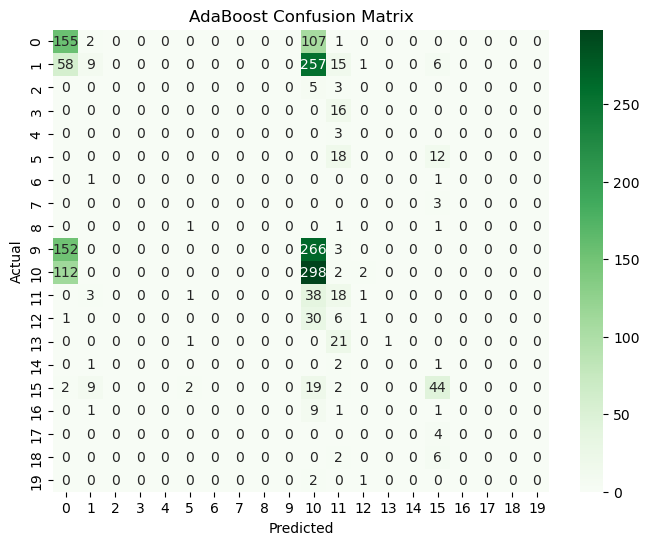

In [29]:
from sklearn.ensemble import AdaBoostClassifier

# Train AdaBoost
ada = AdaBoostClassifier(n_estimators=200, random_state=42)
ada.fit(X_train, y_train)

# Predict
y_pred = ada.predict(X_test)

# Evaluation
print(" AdaBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Greens")
plt.title("AdaBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# Gradient Boosting

 Gradient Boosting Results
Accuracy: 0.4489092996555683

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.48      0.48       265
           1       0.42      0.47      0.44       346
           2       0.20      0.12      0.15         8
           3       0.42      0.50      0.46        16
           4       0.00      0.00      0.00         3
           5       0.65      0.73      0.69        30
           6       1.00      0.50      0.67         2
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         3
           9       0.46      0.49      0.47       421
          10       0.37      0.35      0.36       414
          11       0.54      0.44      0.49        61
          12       0.23      0.08      0.12        38
          13       0.52      0.52      0.52        23
          14       0.50      0.50      0.50         4
          15       0.74      0.73      0.74        78


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


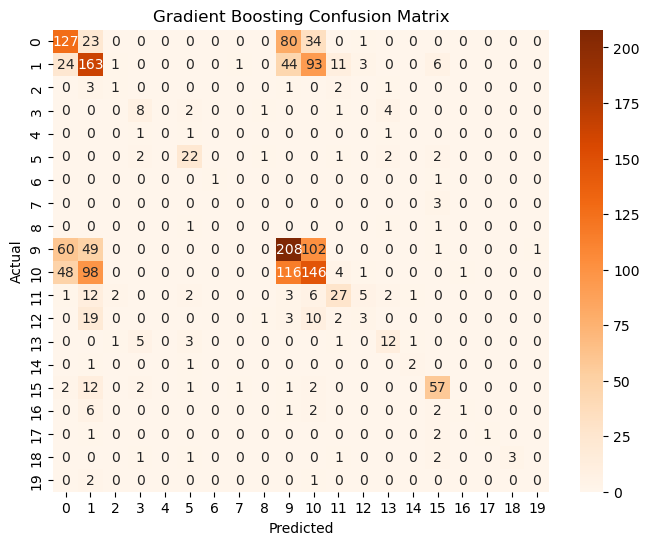

In [28]:
from sklearn.ensemble import GradientBoostingClassifier

# Train Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200, random_state=42)
gb.fit(X_train, y_train)

# Predict
y_pred = gb.predict(X_test)

# Evaluation
print(" Gradient Boosting Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Oranges")
plt.title("Gradient Boosting Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# LightGBM

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000230 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 902
[LightGBM] [Info] Number of data points in the train set: 6964, number of used features: 6
[LightGBM] [Info] Start training from score -1.881542
[LightGBM] [Info] Start training from score -1.617222
[LightGBM] [Info] Start training from score -5.352002
[LightGBM] [Info] Start training from score -4.689626
[LightGBM] [Info] Start training from score -6.363603
[LightGBM] [Info] Start training from score -4.061018
[LightGBM] [Info] Start training from score -6.651285
[LightGBM] [Info] Start training from score -6.450614
[LightGBM] [Info] Start training from score -6.283560
[LightGBM] [Info] Start training from score -1.418988
[LightGBM] [Info] Start training from score -1.436953
[LightGBM] [Info] Start training from score -3.347251
[LightGBM] [Info] Start training from score -3.837874
[LightGBM] [

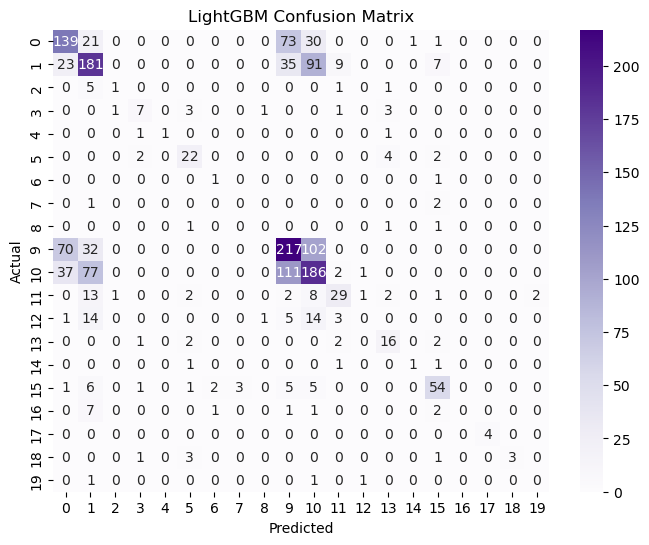

In [35]:
import lightgbm as lgb

# Train LightGBM
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,            # no depth limit
    num_leaves=31,           # more complex leaves
    min_child_samples=5,     # allow smaller leaves
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm.fit(X_train, y_train)

lgbm.fit(X_train, y_train)

# Predict
y_pred = lgbm.predict(X_test)

# Evaluation
print(" LightGBM Results")
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Purples")
plt.title("LightGBM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

import warnings
warnings.filterwarnings("ignore")


# XGBoost

C:\Users\HP\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [13:01:09] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 XGBoost Results
Accuracy: 0.4896670493685419

Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.51      0.51       265
           1       0.50      0.52      0.51       346
           2       0.25      0.12      0.17         8
           3       0.50      0.56      0.53        16
           4       1.00      0.67      0.80         3
           5       0.67      0.73      0.70        30
           6       1.00      0.50      0.67         2
           7       0.00      0.00      0.00         3
           8       0.67      0.67      0.67         3
           9       0.47      0.49      0.48       421
          10       0.42      0.44      0.43       414
          11       0.60      0.49      0.54        61
          12       0.25      0.08      0.12        38
          13       0.58      0.65      0.61        23
          14       0.00      0.00      0.00         4
          15       0.72      0.73      0.73        78
          

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


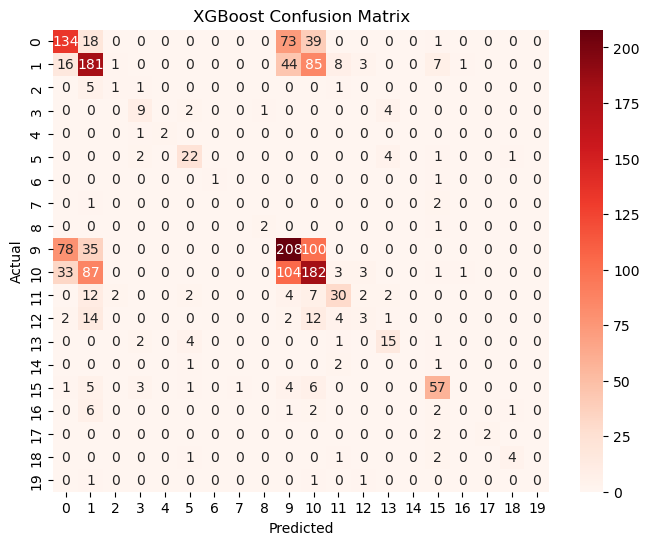

In [33]:
import xgboost as xgb

# Train XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=200, use_label_encoder=False, eval_metric="mlogloss", random_state=42)
xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)

# Evaluation
print(" XGBoost Results")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Reds")
plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
